In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import MSTL

In [ ]:
url = "https://raw.githubusercontent.com/tidyverts/tsibbledata/master/data-raw/vic_elec/VIC2015/demand.csv"
df = pd.read_csv(url)
df

,Date,Period,OperationalLessIndustrial,Industrial
0,37257,1,3535.867064,1086.132936
1,37257,2,3383.499028,1088.500972
2,37257,3,3655.527552,1084.472448
3,37257,4,3510.446636,1085.553364
4,37257,5,3294.697156,1081.302844
...,...,...,...,...
230779,42064,44,NaN,NaN
230780,42064,45,NaN,NaN
230781,42064,46,NaN,NaN
230782,42064,47,NaN,NaN


In [ ]:
df["Date"] = df["Date"].apply(
    lambda x: pd.Timestamp("1899-12-30") + pd.Timedelta(x, unit="days")
)

df





,Date,Period,OperationalLessIndustrial,Industrial
0,2002-01-01,1,3535.867064,1086.132936
1,2002-01-01,2,3383.499028,1088.500972
2,2002-01-01,3,3655.527552,1084.472448
3,2002-01-01,4,3510.446636,1085.553364
4,2002-01-01,5,3294.697156,1081.302844
...,...,...,...,...
230779,2015-03-01,44,NaN,NaN
230780,2015-03-01,45,NaN,NaN
230781,2015-03-01,46,NaN,NaN
230782,2015-03-01,47,NaN,NaN


In [ ]:
df["ds"] = df["Date"] + pd.to_timedelta((df["Period"] - 1) * 30, unit="m")

In [ ]:
df

,Date,Period,OperationalLessIndustrial,Industrial,ds
0,2002-01-01,1,3535.867064,1086.132936,2002-01-01 00:00:00
1,2002-01-01,2,3383.499028,1088.500972,2002-01-01 00:30:00
2,2002-01-01,3,3655.527552,1084.472448,2002-01-01 01:00:00
3,2002-01-01,4,3510.446636,1085.553364,2002-01-01 01:30:00
4,2002-01-01,5,3294.697156,1081.302844,2002-01-01 02:00:00
...,...,...,...,...,...
230779,2015-03-01,44,NaN,NaN,2015-03-01 21:30:00
230780,2015-03-01,45,NaN,NaN,2015-03-01 22:00:00
230781,2015-03-01,46,NaN,NaN,2015-03-01 22:30:00
230782,2015-03-01,47,NaN,NaN,2015-03-01 23:00:00


## TRAINING AND SPLITING THE DATA

We cannot use sklearn.model_selection.train_test_split module because the time series has a inherent chronological order(temporal relationships) which is required but if we use train_test_split it will randomly shuffle all the datasets to reduce selection bias.

In [ ]:
timeseries = df[["ds", "OperationalLessIndustrial"]]
timeseries.columns = [
    "ds",
    "y",
]  # Rename to OperationalLessIndustrial to y for simplicity.

# Filter for first 149 days of 2012.
start_date = pd.to_datetime("2012-01-01")
end_date = start_date + pd.Timedelta("149D")
mask = (timeseries["ds"] >= start_date) & (timeseries["ds"] < end_date)
timeseries = timeseries[mask]

# Resample to hourly
timeseries = timeseries.set_index("ds").resample("h").sum()

# Split data into training and testing sets
test_size = 24 * 7 * 2 # 2 weeks for testing (hourly data)
train_data = timeseries.iloc[:-test_size]
test_data = timeseries.iloc[-test_size:]

print("Training data shape:", train_data.shape)
print("Testing data shape:", test_data.shape)
display(train_data.head())
display(test_data.head())

Training data shape: (3240, 1)
Testing data shape: (336, 1)


,y
ds,
2012-01-01 00:00:00,7926.529376
2012-01-01 01:00:00,7901.826990
2012-01-01 02:00:00,7255.721350
2012-01-01 03:00:00,6792.503352
2012-01-01 04:00:00,6635.984460


,y
ds,
2012-05-15 00:00:00,8821.939726
2012-05-15 01:00:00,8815.029322
2012-05-15 02:00:00,8157.569918
2012-05-15 03:00:00,7710.985372
2012-05-15 04:00:00,7637.993618


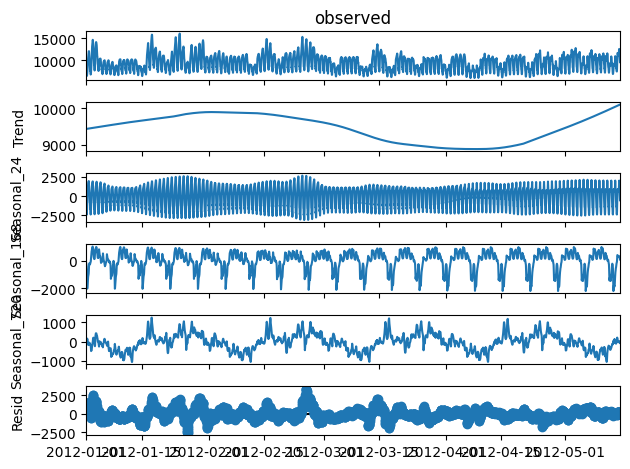

In [ ]:
mstl = MSTL(
    train_data["y"],
    periods=[24, 24 * 7, 720],
    iterate=3,
    stl_kwargs={"seasonal_deg": 0, "inner_iter": 2, "outer_iter": 0},
)
res = mstl.fit()  # Use .fit() to perform and return the decomposition
ax = res.plot()
plt.tight_layout()

In [ ]:
res.

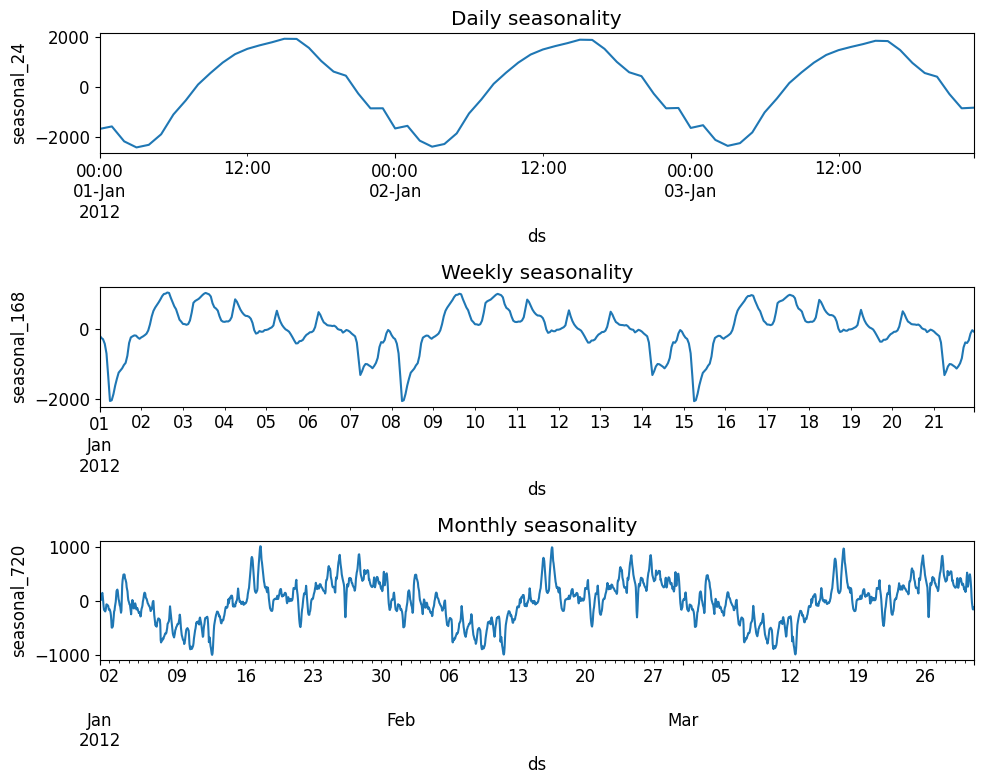

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=[10, 8])
res.seasonal["seasonal_24"].iloc[: 24 * 3].plot(ax=ax[0])
ax[0].set_ylabel("seasonal_24")
ax[0].set_title("Daily seasonality")

res.seasonal["seasonal_168"].iloc[: 24 * 7 * 3].plot(ax=ax[1])
ax[1].set_ylabel("seasonal_168")
ax[1].set_title("Weekly seasonality")

res.seasonal["seasonal_720"].iloc[: 24 * 30 * 3].plot(ax=ax[2])
ax[2].set_ylabel("seasonal_720")
ax[2].set_title("Monthly seasonality")

plt.tight_layout()
plt.savefig("all_seasonalities.png")

In [ ]:
# Get all attributes of the 'res' object
all_attributes = dir(res)

# Separate methods (callable attributes) from other attributes
methods = [attr for attr in all_attributes if callable(getattr(res, attr)) and not attr.startswith('__')]
attributes = [attr for attr in all_attributes if not callable(getattr(res, attr)) and not attr.startswith('__')]

print("Attributes of the 'res' object:")
for attr in sorted(attributes):
    print(f"- {attr}")

print("\nMethods of the 'res' object:")
for method in sorted(methods):
    print(f"- {method}")

Attributes of the 'res' object:
- _observed
- _resid
- _seasonal
- _trend
- _weights
- nobs
- observed
- resid
- seasonal
- trend
- weights

Methods of the 'res' object:
- plot


In [ ]:
original_variance = train_data['y'].var()

daily_seasonal_variance = res.seasonal['seasonal_24'].var()
weekly_seasonal_variance = res.seasonal['seasonal_168'].var()
monthly_seasonal_variance = res.seasonal['seasonal_720'].var()

print(f"Original time series variance (train data): {original_variance:.2f}")
print(f"Daily seasonality strength: {daily_seasonal_variance / original_variance:.4f}")
print(f"Weekly seasonality strength: {weekly_seasonal_variance / original_variance:.4f}")
print(f"Monthly seasonality strength: {monthly_seasonal_variance / original_variance:.4f}")

Original time series variance (train data): 3059748.42
Daily seasonality strength: 0.5616
Weekly seasonality strength: 0.1600
Monthly seasonality strength: 0.0576


### Forecasting with MSTL Components

To forecast, we'll individually forecast the trend and residuals, and extend the seasonal components by repeating their patterns. Then, we combine them to get the final forecast.

In [ ]:
from statsmodels.tsa.api import ExponentialSmoothing

# Define forecast horizon as the length of the test data
forecast_steps = len(test_data)

# Create a future date index for forecasting (aligns with test_data index)
future_dates = test_data.index

# 1. Forecast the Trend Component using Exponential Smoothing on training data
trend_model = ExponentialSmoothing(res.trend, trend='add', seasonal=None, initialization_method="estimated").fit()
forecasted_trend = trend_model.forecast(forecast_steps)

# 2. Forecast Seasonal Components by repeating the last cycle from training data
def repeat_seasonal(seasonal_component, steps, index):
    period = len(seasonal_component)
    repeated_seasonal = np.tile(seasonal_component, int(np.ceil(steps / period)))[:steps]
    return pd.Series(repeated_seasonal, index=index)

forecasted_seasonal_24 = repeat_seasonal(res.seasonal['seasonal_24'].iloc[-24:], forecast_steps, future_dates)
forecasted_seasonal_168 = repeat_seasonal(res.seasonal['seasonal_168'].iloc[-168:], forecast_steps, future_dates)
forecasted_seasonal_720 = repeat_seasonal(res.seasonal['seasonal_720'].iloc[-720:], forecast_steps, future_dates)

# 3. Forecast Residuals (assume 0 for simplicity, or model them if significant)
forecasted_residuals = pd.Series(0, index=future_dates)

# 4. Combine all components for the final forecast
final_forecast = forecasted_trend + forecasted_seasonal_24 + forecasted_seasonal_168 + forecasted_seasonal_720 + forecasted_residuals

print("Forecasted Trend (first 5):")
display(forecasted_trend.head())
print("Forecasted Daily Seasonality (first 5):")
display(forecasted_seasonal_24.head())
print("Final Forecast (first 5):")
display(final_forecast.head())

Forecasted Trend (first 5):


,0
2012-05-15 00:00:00,10102.090761
2012-05-15 01:00:00,10104.178202
2012-05-15 02:00:00,10106.265643
2012-05-15 03:00:00,10108.353085
2012-05-15 04:00:00,10110.440526


Forecasted Daily Seasonality (first 5):


,0
ds,
2012-05-15 00:00:00,-1334.230585
2012-05-15 01:00:00,-1319.407544
2012-05-15 02:00:00,-1889.743341
2012-05-15 03:00:00,-2296.294857
2012-05-15 04:00:00,-2374.240767


Final Forecast (first 5):


,0
2012-05-15 00:00:00,8744.731028
2012-05-15 01:00:00,8775.008715
2012-05-15 02:00:00,8249.216878
2012-05-15 03:00:00,7868.217270
2012-05-15 04:00:00,7928.079145


### Visualize MSTL (Exponential Smoothing) Forecast vs. Actual Values

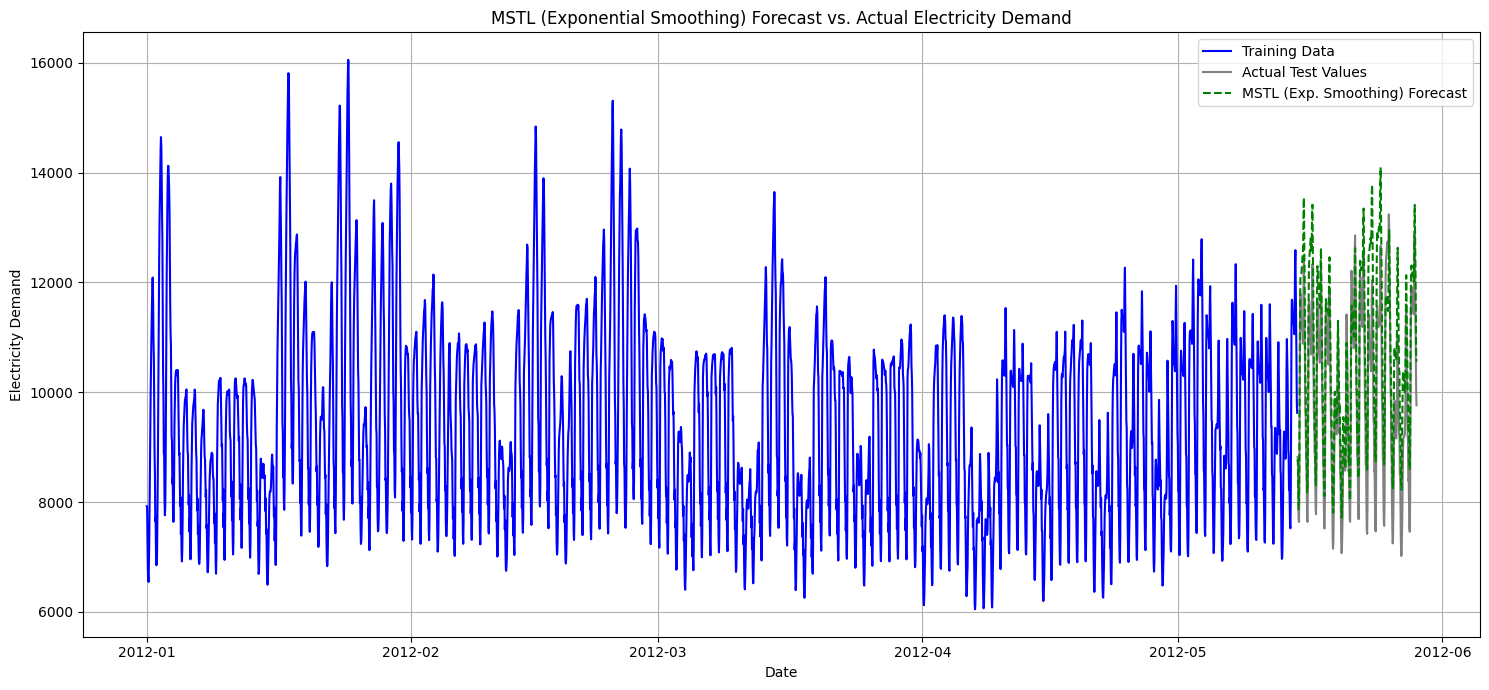

In [77]:
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data['y'], label='Training Data', color='blue')
plt.plot(test_data.index, test_data['y'], label='Actual Test Values', color='gray')
plt.plot(final_forecast.index, final_forecast, label='MSTL (Exp. Smoothing) Forecast', color='green', linestyle='--')

plt.title('MSTL (Exponential Smoothing) Forecast vs. Actual Electricity Demand')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Forecasting with SARIMA (Seasonal ARIMA)

### Forecasting with ARIMA on MSTL Residuals

In [81]:
from statsmodels.tsa.arima.model import ARIMA

# Get the residuals from the MSTL decomposition on the training data
residuals_train = res.resid

# Define the p, d, q parameters to take any value between 0 and 2
p = d = q = range(0, 3)

# Generate all different combinations of p, d, q triplets
pdq_combinations = list(itertools.product(p, d, q))

print('ARIMA model parameter combinations:')
print('Non-seasonal (p,d,q):', pdq_combinations)

def evaluate_arima_model(data, order):
    # Evaluate an ARIMA model for a given order
    try:
        model = ARIMA(
            data,
            order=order,
            enforce_stationarity=False,
            enforce_invertibility=False,
            freq='h'
        )
        model_fit = model.fit() # Removed disp=False
        return model_fit.aic
    except Exception as e:
        print(f"Error with ARIMA{order}: {e}") # Uncommented for debugging
        return float('inf')


# Grid search for the best ARIMA parameters on residuals
best_aic = float('inf')
best_order = None

for order in pdq_combinations:
    aic = evaluate_arima_model(residuals_train, order)
    if aic < best_aic:
        best_aic = aic
        best_order = order
    print(f'ARIMA{order} AIC: {aic:.2f}')

print(f'Best ARIMA order for residuals: {best_order} with AIC: {best_aic:.2f}')

ARIMA model parameter combinations:
Non-seasonal (p,d,q): [(0, 0, 0), (0, 0, 1), (0, 0, 2), (0, 1, 0), (0, 1, 1), (0, 1, 2), (0, 2, 0), (0, 2, 1), (0, 2, 2), (1, 0, 0), (1, 0, 1), (1, 0, 2), (1, 1, 0), (1, 1, 1), (1, 1, 2), (1, 2, 0), (1, 2, 1), (1, 2, 2), (2, 0, 0), (2, 0, 1), (2, 0, 2), (2, 1, 0), (2, 1, 1), (2, 1, 2), (2, 2, 0), (2, 2, 1), (2, 2, 2)]
ARIMA(0, 0, 0) AIC: 51039.09
ARIMA(0, 0, 1) AIC: 46713.88
ARIMA(0, 0, 2) AIC: 43428.01
ARIMA(0, 1, 0) AIC: 39265.51
ARIMA(0, 1, 1) AIC: 37280.22
ARIMA(0, 1, 2) AIC: 36742.95
ARIMA(0, 2, 0) AIC: 37107.10
ARIMA(0, 2, 1) AIC: 37089.78
ARIMA(0, 2, 2) AIC: 36961.73
ARIMA(1, 0, 0) AIC: 39259.29
ARIMA(1, 0, 1) AIC: 37262.64
ARIMA(1, 0, 2) AIC: 36709.94
ARIMA(1, 1, 0) AIC: 36673.18
ARIMA(1, 1, 1) AIC: 36533.40
ARIMA(1, 1, 2) AIC: 36524.38
ARIMA(1, 2, 0) AIC: 37103.66
ARIMA(1, 2, 1) AIC: 37061.08
ARIMA(1, 2, 2) AIC: 36519.78
ARIMA(2, 0, 0) AIC: 36527.76
ARIMA(2, 0, 1) AIC: 36436.61
ARIMA(2, 0, 2) AIC: 36425.20
ARIMA(2, 1, 0) AIC: 36539.53
ARIMA(

### Fit ARIMA on Residuals and Generate Improved Forecast

In [82]:
# Fit ARIMA model to the training residuals with the best order
arima_residuals_model = ARIMA(
    residuals_train,
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False,
    freq='h'
)
arima_residuals_model_fit = arima_residuals_model.fit()

# Forecast the residuals for the test period
forecasted_arima_residuals = arima_residuals_model_fit.forecast(steps=forecast_steps)
forecasted_arima_residuals.index = future_dates

# Combine the MSTL forecast (trend + seasonal) with the forecasted ARIMA residuals
final_forecast_improved = forecasted_trend + forecasted_seasonal_24 + forecasted_seasonal_168 + forecasted_seasonal_720 + forecasted_arima_residuals

print("Forecasted ARIMA Residuals (first 5):")
display(forecasted_arima_residuals.head())
print("Improved Final Forecast (first 5) combining MSTL and ARIMA residuals:")
display(final_forecast_improved.head())

Forecasted ARIMA Residuals (first 5):


,predicted_mean
ds,
2012-05-15 00:00:00,12.580855
2012-05-15 01:00:00,-2.884138
2012-05-15 02:00:00,-13.700304
2012-05-15 03:00:00,-21.059961
2012-05-15 04:00:00,-25.865747


Improved Final Forecast (first 5) combining MSTL and ARIMA residuals:


,0
2012-05-15 00:00:00,8757.311883
2012-05-15 01:00:00,8772.124577
2012-05-15 02:00:00,8235.516574
2012-05-15 03:00:00,7847.157309
2012-05-15 04:00:00,7902.213398


### Evaluate Improved Forecast Accuracy (MSTL + ARIMA Residuals)

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true = test_data['y']
y_pred_improved = final_forecast_improved

# Calculate MAE
mae_improved = mean_absolute_error(y_true, y_pred_improved)

# Calculate MSE
mse_improved = mean_squared_error(y_true, y_pred_improved)

# Calculate RMSE
rmse_improved = np.sqrt(mse_improved)

# Calculate MAPE (handling zero values in y_true)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Avoid division by zero
    return np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100

mape_improved = mean_absolute_percentage_error(y_true, y_pred_improved)

print(f"Improved Mean Absolute Error (MAE): {mae_improved:.2f}")
print(f"Improved Mean Squared Error (MSE): {mse_improved:.2f}")
print(f"Improved Root Mean Squared Error (RMSE): {rmse_improved:.2f}")
print(f"Improved Mean Absolute Percentage Error (MAPE): {mape_improved:.2f}%")

# Compare with previous MSTL-only forecast accuracy (if available)
# Assuming `mae`, `mse`, `rmse`, `mape` variables from previous MSTL evaluation are still available in kernel state
print("\n--- Comparison with MSTL-only Forecast ---")
print(f"Original MSTL MAE: {mae:.2f}")
print(f"Original MSTL MSE: {mse:.2f}")
print(f"Original MSTL RMSE: {rmse:.2f}")
print(f"Original MSTL MAPE: {mape:.2f}%")

Improved Mean Absolute Error (MAE): 772.77
Improved Mean Squared Error (MSE): 829854.78
Improved Root Mean Squared Error (RMSE): 910.96
Improved Mean Absolute Percentage Error (MAPE): 7.89%

--- Comparison with MSTL-only Forecast ---
Original MSTL MAE: 781.94
Original MSTL MSE: 845264.69
Original MSTL RMSE: 919.38
Original MSTL MAPE: 7.99%


### Comparison: SARIMA vs. MSTL + ARIMA Residuals

In [ ]:
print("--- Performance Comparison ---")
print("\n--- MSTL + ARIMA Residuals ---")
print(f"MAE: {mae_improved:.2f}")
print(f"MSE: {mse_improved:.2f}")
print(f"RMSE: {rmse_improved:.2f}")
print(f"MAPE: {mape_improved:.2f}%")

print("\n--- SARIMA (on Original Data) ---")
print(f"MAE: {mae_sarima:.2f}")
print(f"MSE: {mse_sarima:.2f}")
print(f"RMSE: {rmse_sarima:.2f}")
print(f"MAPE: {mape_sarima:.2f}%")

if mae_improved < mae_sarima:
    print("\nConclusion: The MSTL + ARIMA Residuals approach yields better accuracy (lower MAE, MSE, RMSE, MAPE) compared to the SARIMA model implemented directly on the original data.")
else:
    print("\nConclusion: The SARIMA model implemented directly on the original data yields better accuracy (lower MAE, MSE, RMSE, MAPE) compared to the MSTL + ARIMA Residuals approach.")

In [71]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import itertools

# Define the p, d, q parameters to take any value between 0 and 1
p = d = q = range(0, 2)

# Generate all different combinations of p, d, q triplets
pdq = list(itertools.product(p, d, q))

# Define the seasonal p, d, q parameters to take any value between 0 and 1
P = D = Q = range(0, 2)

# Generate all different combinations of seasonal p, d, q triplets
seasonal_pdq = [(x[0], x[1], x[2], 24) for x in list(itertools.product(P, D, Q))]

print('SARIMA model parameter combinations:')
print('Non-seasonal (p,d,q):', pdq)
print('Seasonal (P,D,Q,s):', seasonal_pdq)


def evaluate_sarima_model(data, order, seasonal_order):
    # Evaluate a SARIMA model for a given order and seasonal order
    try:
        model = SARIMAX(
            data,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False,
            freq='h'
        )
        model_fit = model.fit(disp=False) # disp=False to suppress convergence messages
        return model_fit.aic
    except Exception as e:
        # print(f"Error with SARIMA{order}{seasonal_order}: {e}") # Uncomment for debugging
        return float('inf')


# Grid search for the best SARIMA parameters
best_aic_sarima = float('inf')
best_order_sarima = None
best_seasonal_order_sarima = None

for order in pdq:
    for s_order in seasonal_pdq:
        aic = evaluate_sarima_model(train_data['y'], order, s_order)
        if aic < best_aic_sarima:
            best_aic_sarima = aic
            best_order_sarima = order
            best_seasonal_order_sarima = s_order
        print(f'SARIMA{order}{s_order} AIC: {aic:.2f}')

print(f'Best SARIMA order: {best_order_sarima}{best_seasonal_order_sarima} with AIC: {best_aic_sarima:.2f}')


SARIMA model parameter combinations:
Non-seasonal (p,d,q): [(0, 0, 0), (0, 0, 1), (0, 1, 0), (0, 1, 1), (1, 0, 0), (1, 0, 1), (1, 1, 0), (1, 1, 1)]
Seasonal (P,D,Q,s): [(0, 0, 0, 24), (0, 0, 1, 24), (0, 1, 0, 24), (0, 1, 1, 24), (1, 0, 0, 24), (1, 0, 1, 24), (1, 1, 0, 24), (1, 1, 1, 24)]
SARIMA(0, 0, 0)(0, 0, 0, 24) AIC: 68575.79
SARIMA(0, 0, 0)(0, 0, 1, 24) AIC: 65771.61
SARIMA(0, 0, 0)(0, 1, 0, 24) AIC: 54284.79
SARIMA(0, 0, 0)(0, 1, 1, 24) AIC: 53822.28
SARIMA(0, 0, 0)(1, 0, 0, 24) AIC: 54294.15
SARIMA(0, 0, 0)(1, 0, 1, 24) AIC: 54214.13
SARIMA(0, 0, 0)(1, 1, 0, 24) AIC: 53851.52
SARIMA(0, 0, 0)(1, 1, 1, 24) AIC: 53660.73
SARIMA(0, 0, 1)(0, 0, 0, 24) AIC: 66164.33
SARIMA(0, 0, 1)(0, 0, 1, 24) AIC: 65075.40
SARIMA(0, 0, 1)(0, 1, 0, 24) AIC: 50040.35
SARIMA(0, 0, 1)(0, 1, 1, 24) AIC: 49599.96
SARIMA(0, 0, 1)(1, 0, 0, 24) AIC: 50071.77
SARIMA(0, 0, 1)(1, 0, 1, 24) AIC: 49967.30
SARIMA(0, 0, 1)(1, 1, 0, 24) AIC: 49646.99
SARIMA(0, 0, 1)(1, 1, 1, 24) AIC: 49461.98
SARIMA(0, 1, 0)(0, 0, 0

After identifying the best SARIMA parameters using the grid search, we will now fit the SARIMA model to the training data and generate forecasts for the test period.

In [72]:
# Fit SARIMA model with the best parameters
sarima_model = SARIMAX(
    train_data['y'],
    order=best_order_sarima,
    seasonal_order=best_seasonal_order_sarima,
    enforce_stationarity=False,
    enforce_invertibility=False,
    freq='h'
)
sarima_model_fit = sarima_model.fit(disp=False)

# Forecast for the test period
sarima_forecast = sarima_model_fit.forecast(steps=forecast_steps)
sarima_forecast.index = future_dates

print("SARIMA Forecast (first 5):")
display(sarima_forecast.head())


SARIMA Forecast (first 5):


,predicted_mean
ds,
2012-05-15 00:00:00,8885.587508
2012-05-15 01:00:00,8969.007496
2012-05-15 02:00:00,8443.565258
2012-05-15 03:00:00,8029.122050
2012-05-15 04:00:00,7961.148593


### Visualize SARIMA Forecast vs. Actual Values

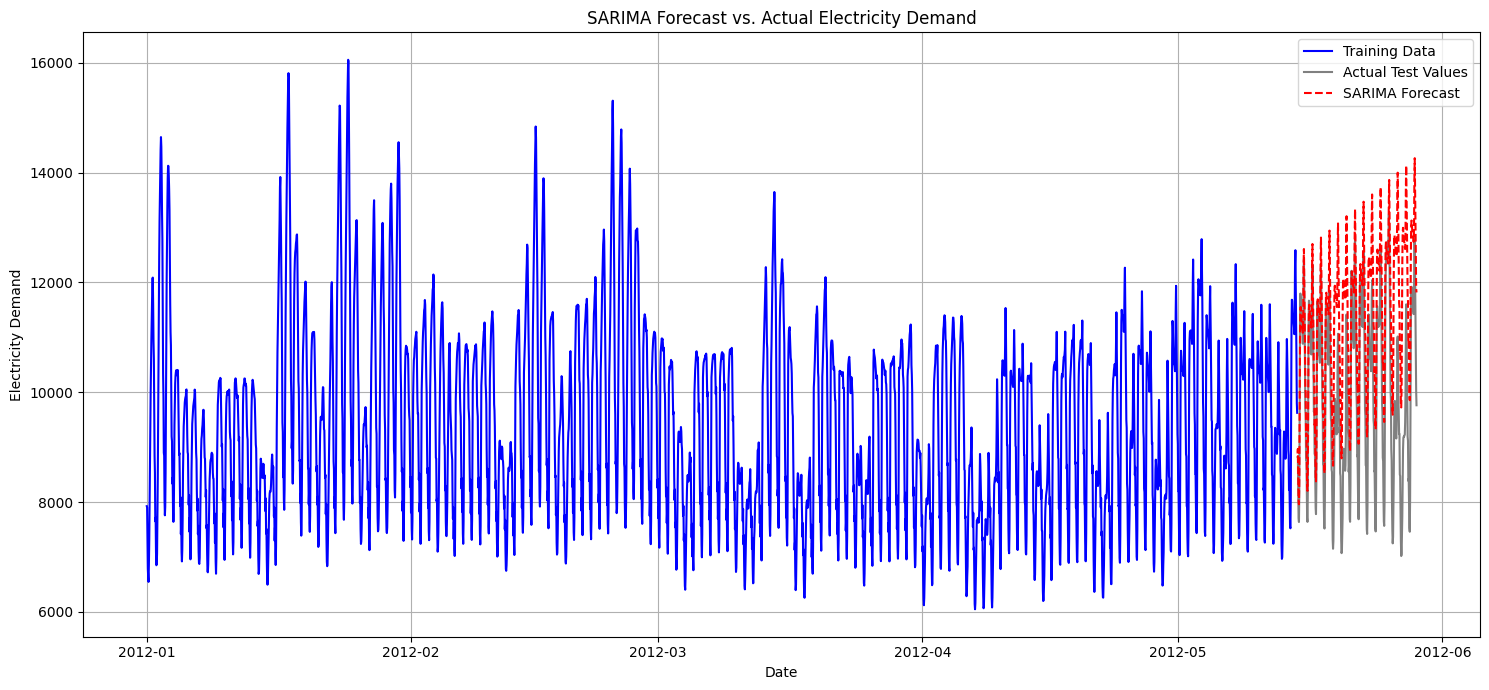

In [73]:
plt.figure(figsize=(15, 7))
plt.plot(train_data.index, train_data['y'], label='Training Data', color='blue')
plt.plot(test_data.index, test_data['y'], label='Actual Test Values', color='gray')
plt.plot(sarima_forecast.index, sarima_forecast, label='SARIMA Forecast', color='red', linestyle='--')

plt.title('SARIMA Forecast vs. Actual Electricity Demand')
plt.xlabel('Date')
plt.ylabel('Electricity Demand')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


### Evaluate SARIMA Forecast Accuracy

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

y_true_sarima = test_data['y']
y_pred_sarima = sarima_forecast

# Calculate MAE
mae_sarima = mean_absolute_error(y_true_sarima, y_pred_sarima)

# Calculate MSE
mse_sarima = mean_squared_error(y_true_sarima, y_pred_sarima)

# Calculate RMSE
rmse_sarima = np.sqrt(mse_sarima)

# Calculate MAPE (handling zero values in y_true)
def mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true[y_true != 0])) * 100

mape_sarima = mean_absolute_percentage_error(y_true_sarima, y_pred_sarima)

print(f"SARIMA Mean Absolute Error (MAE): {mae_sarima:.2f}")
print(f"SARIMA Mean Squared Error (MSE): {mse_sarima:.2f}")
print(f"SARIMA Root Mean Squared Error (RMSE): {rmse_sarima:.2f}")
print(f"SARIMA Mean Absolute Percentage Error (MAPE): {mape_sarima:.2f}%")


SARIMA Mean Absolute Error (MAE): 1368.81
SARIMA Mean Squared Error (MSE): 2822803.29
SARIMA Root Mean Squared Error (RMSE): 1680.12
SARIMA Mean Absolute Percentage Error (MAPE): 14.76%


### SARIMA Forecast Residual Analysis

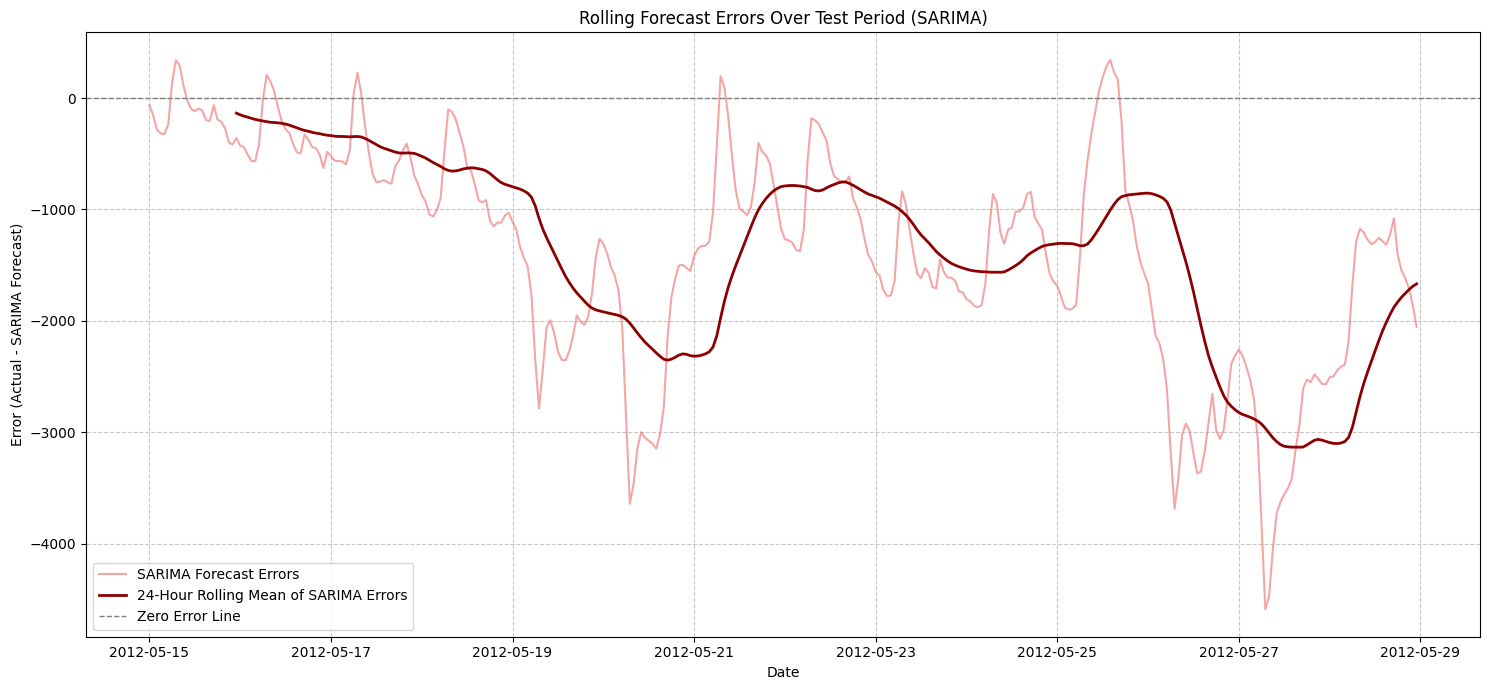

Summary statistics for SARIMA residuals:


,0
count,336.000000
mean,-1349.831531
std,1001.870981
min,-4590.181240
25%,-1884.314656
50%,-1218.099036
75%,-561.274412
max,343.565825


In [75]:
sarima_residuals = y_true_sarima - y_pred_sarima

# Rolling mean of residuals
rolling_mean_sarima_residuals = sarima_residuals.rolling(window=24).mean()

plt.figure(figsize=(15, 7))
plt.plot(sarima_residuals.index, sarima_residuals, label='SARIMA Forecast Errors', color='lightcoral', alpha=0.7)
plt.plot(rolling_mean_sarima_residuals.index, rolling_mean_sarima_residuals, label='24-Hour Rolling Mean of SARIMA Errors', color='darkred', linewidth=2)
plt.axhline(0, color='gray', linestyle='--', linewidth=1, label='Zero Error Line')

plt.title('Rolling Forecast Errors Over Test Period (SARIMA)')
plt.xlabel('Date')
plt.ylabel('Error (Actual - SARIMA Forecast)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Summary statistics for SARIMA residuals:")
display(sarima_residuals.describe())


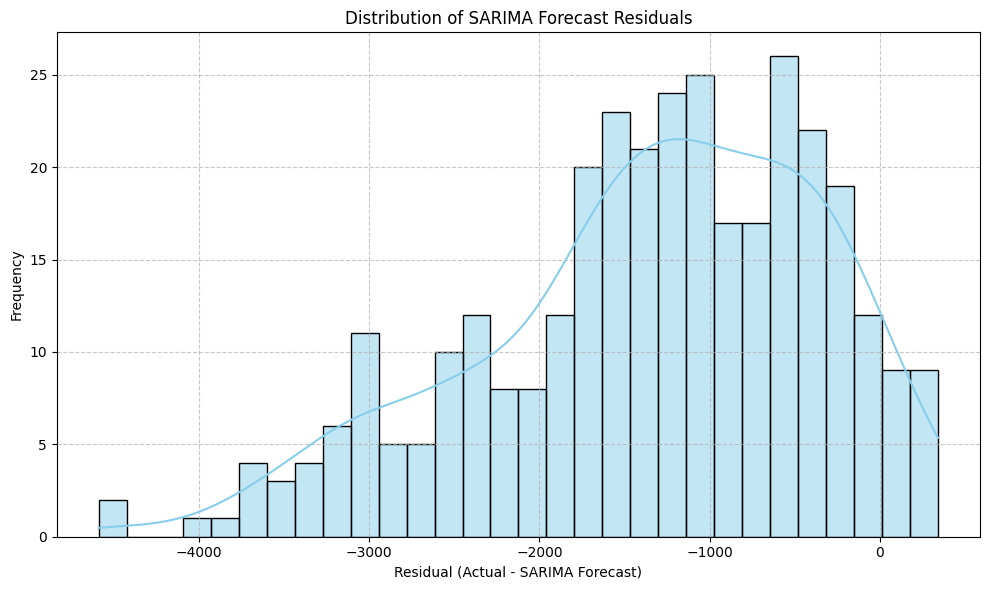

In [84]:
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(sarima_residuals, kde=True, color='skyblue', bins=30)
plt.title('Distribution of SARIMA Forecast Residuals')
plt.xlabel('Residual (Actual - SARIMA Forecast)')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### ACF and PACF Plots for SARIMA Residuals

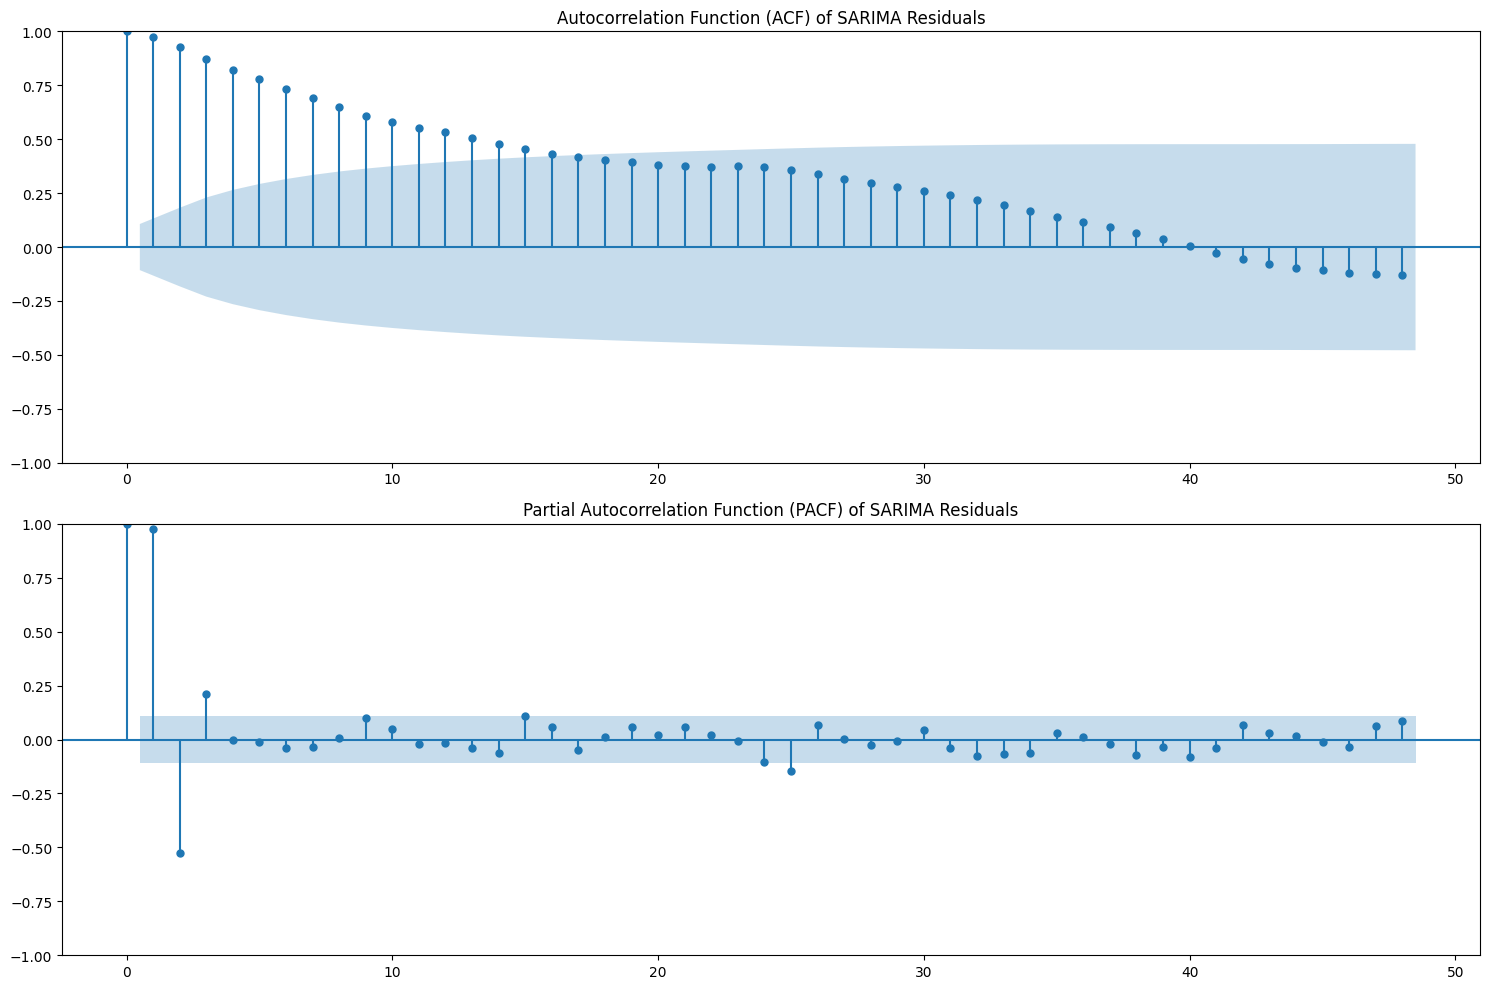

In [78]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_acf(sarima_residuals, lags=48, ax=axes[0], title='Autocorrelation Function (ACF) of SARIMA Residuals')
plot_pacf(sarima_residuals, lags=48, ax=axes[1], title='Partial Autocorrelation Function (PACF) of SARIMA Residuals')

plt.tight_layout()
plt.show()